In [431]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range,
    get_mlruns_info
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [432]:
os.getuid()

1000

In [ ]:
DECAY_RATE = 1

# Only used for pivot table
end_datetime_str = start_datetime_str = "2024-11-13 17-38-28" # Laptop
# end_datetime_str = start_datetime_str = "2024-11-13 18-25-28" # Server
# end_datetime_str = start_datetime_str = "2024-11-13 19-10-58" # Azure2
# end_datetime_str = start_datetime_str = "2024-11-13 20-32-27" # Server

# end_datetime_str = start_datetime_str = "2024-11-13 22-48-46" # Server
# end_datetime_str = start_datetime_str = "2024-11-14 01-18-39" # Server

# Range
start_datetime_str = "2024-11-13 17-38-28"
end_datetime_str = 

single_load = True

if single_load:
    df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
    
    if start_datetime_str == end_datetime_str:
        actor_df = get_mlruns_info(start_datetime_str, 
                                    end_datetime_str,
                                    reload=False,)
        actor_df["experiment_path"] = df.experiment_path.unique()[0]
else:
    files = [
        "2024-11-13 17-38-28", # Line Following large
        "2024-11-13 19-10-58", # Line Following small

        "2024-11-13 18-25-28", # Robot Pursuit large
        "2024-11-13 20-32-27", # Robot Pursuit small

        # "2024-11-13 01-42-56", # Pushing Object small
    ]

    final_df = None
    final_actor_dfs = None
    for time_n in files:
        print("time_n:", time_n)
        end_datetime_str = start_datetime_str = time_n
        df = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                    )
        actor_df = get_mlruns_info(start_datetime_str, 
                                    end_datetime_str)
        actor_df["experiment_path"] = df.experiment_path.unique()[0]

        if final_df is None:
            final_df = df.copy()
            final_actor_dfs = actor_df.copy()

        else:
            final_df = pd.concat([final_df, df])
            final_actor_dfs = pd.concat([final_actor_dfs, actor_df])
    
    df = final_df
    actor_df = final_actor_dfs
# end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
# df_2 = get_df_from_datetime_range(start_datetime_str, 
#                                 end_datetime_str, 
#                                 decay_rate=DECAY_RATE,
#                                 max_iter=np.inf,
#                                 validity_check=False,
#                                 reload=False
#                                 )

# df = pd.concat([df, df_2])

# df.head()
actor_df.head()

,time,actor_loss,step_id,run_name,experiment_path
0,1731519598050,0.071572,300,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
1,1731519630504,0.000744,400,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
2,1731519665035,-0.059290,500,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
3,1731519699698,-0.094939,600,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...
4,1731519735186,-0.141714,700,2024-11-13 17-38-28 0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...


In [434]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

df = df.sort_values(["experiment_path", "iteration_id", "step_id"])
df["trained_task"] = df.apply(lambda row: row.task_name if row.phase == "train" else pd.NA, axis=1)
df["trained_task"] = df.trained_task.fillna(method='ffill')
df

/tmp/ipykernel_1173383/3738003492.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 299,absolute_path,exp_config,experiment_path,category,controller,is_reset_buffer,buffer_size,learning_starts,trained_task
0,0.000,0.489796,None,0.489796,1,1,circle_red,0,train,True,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_red
1,0.000,0.285714,None,0.775510,1,1,circle_red,1,train,True,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_red
2,0.165,0.244898,None,1.020408,1,1,circle_red,2,train,True,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_red
3,0.330,0.244898,None,1.265306,1,1,circle_red,3,train,True,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_red
4,0.495,0.163265,None,1.428571,1,1,circle_red,4,train,True,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,3.960,0.979592,None,24.857143,1,1037,circle_yellow,895,eval,False,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_yellow
26,4.125,0.938776,None,25.795918,1,1037,circle_yellow,896,eval,False,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_yellow
27,4.290,0.979592,None,26.775510,1,1037,circle_yellow,897,eval,False,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_yellow
28,4.455,0.979592,None,27.755102,1,1037,circle_yellow,898,eval,False,...,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,LineFollowing,SAC,False,20000,250,circle_yellow


In [435]:
[c for c in df.columns if "pos" in c]

['robot_position']

In [436]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           LineFollowing
controller                   SAC
is_reset_buffer            False
buffer_size                20000
Name: 0, dtype: object

In [437]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

,,,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 296,Image pixel 297,Image pixel 298,Image pixel 299,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts,trained_task
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,
SAC,LineFollowing,20000,4.62,0.938776,None,28.693878,1,1037,circle_yellow,899,eval,False,...,0.0,0.0,0.0,0.0,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_yellow


In [438]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'LineFollowing', 20000))

In [439]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'LineFollowing', 20000)],
           names=['controller', 'category', 'buffer_size'])

In [440]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [441]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [442]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

# Graph

/tmp/ipykernel_1173383/2710623390.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(X_, Y_, degree)
/tmp/ipykernel_1173383/2710623390.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend()


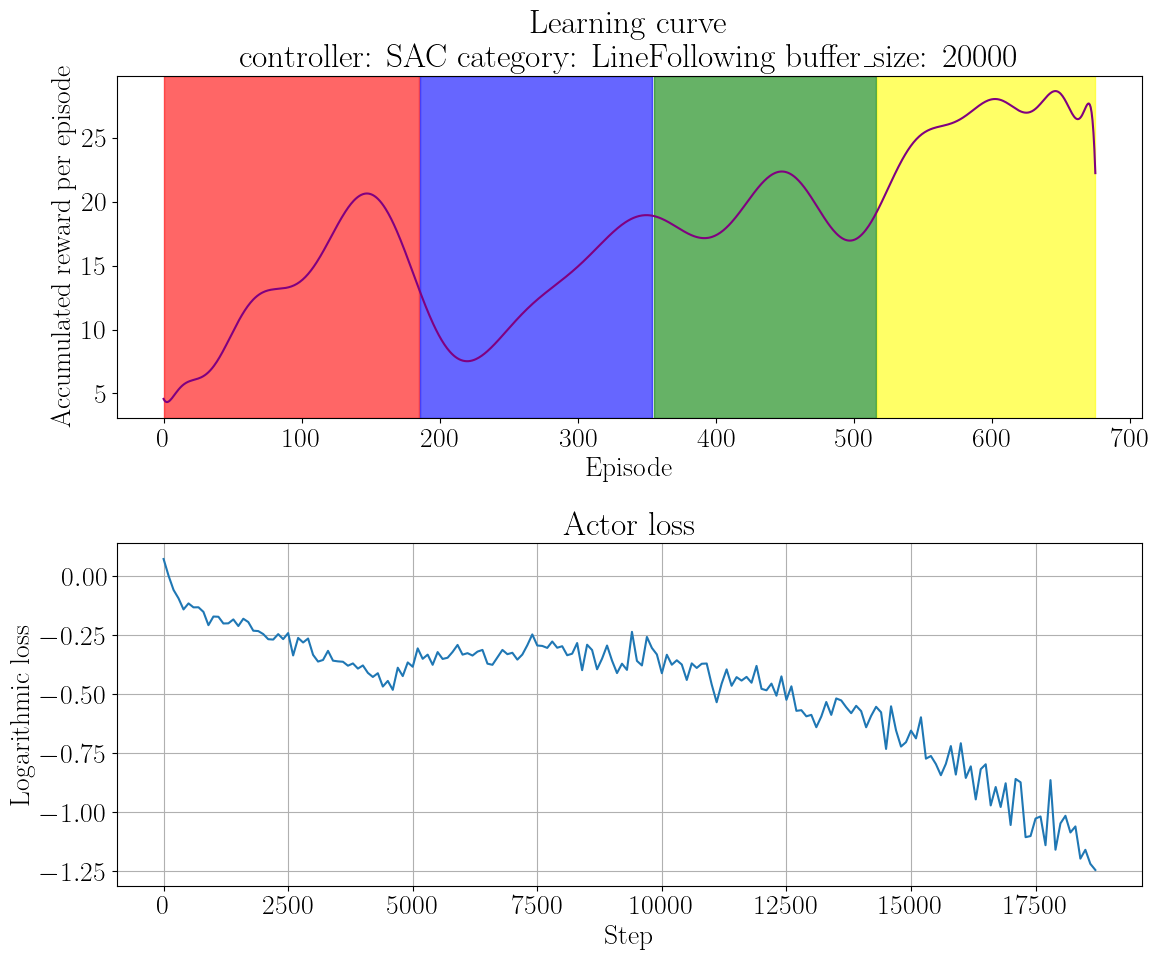

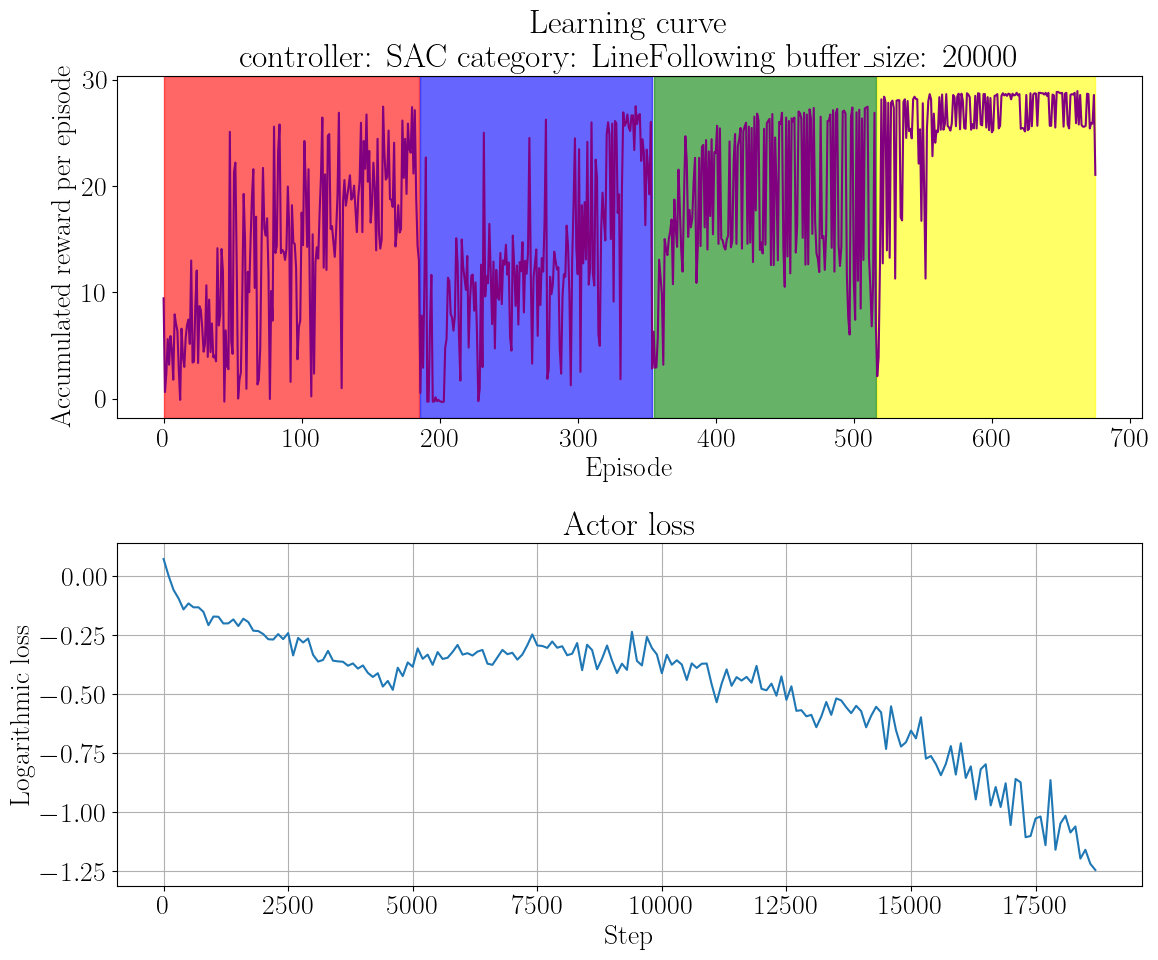

In [443]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20
})
# import matplotlib
# %matplotlib inline

def interpolate(X_, Y_):
    N_SAMPLE_INTER=1000

    degree = 30
    coeffs = np.polyfit(X_, Y_, degree)
    X_ = np.linspace(X_.min(), X_.max(), N_SAMPLE_INTER)
    Y_ = np.polyval(coeffs, X_)

    return X_, Y_

def plot_learning_curve(index, index_names, df, title="Learning curve", ax=None, use_interpolate=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index

    if not use_interpolate:
        tmp_group_df = tmp_group_df.set_index("iteration_id")
        tmp_group_df.plot(y="current_undiscounted_value", ax=ax, color="purple")
    else:
        ax.plot(*interpolate(tmp_group_df.iteration_id, tmp_group_df.current_undiscounted_value), color="purple")
        

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.6, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()

    return "_".join([f"{a}_{b}" for a, b in list(zip(index_names, index))]) + "_interp_{}".format(1 if use_interpolate else 0)


for id in group_df.index:
    for interp in [True, False]:
        fig, ax = plt.subplots(2, 1, figsize=(12, 10))
        title = plot_learning_curve(id, 
                                    group_df.index.names, 
                                    df[df.phase=="train"], 
                                    ax=ax[0],
                                    use_interpolate=interp)
        
        actor_df["steps"] = [100 * i for i in range(len(actor_df))]
        actor_df[actor_df.experiment_path == df.experiment_path.values[0]].plot(x="steps", y="actor_loss", ax=ax[1])
        ax[1].set_title("Actor loss")
        ax[1].set_ylabel("Logarithmic loss")
        ax[1].set_xlabel("Step")
        ax[1].legend().remove()
        ax[1].grid()
        # plot_learning_curve(group_df.index[1], group_df.index.names, df)
        # plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
        # plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
        # plt.show()
        plt.tight_layout()
        os.makedirs("./media", exist_ok=True)
        fig.savefig("./media/{}.pdf".format(title))

In [444]:
df[df.phase=="train"].set_index("iteration_id").current_undiscounted_value.values[-30:]

array([21.83673469, 22.81632653, 23.75510204, 24.73469388, 25.67346939,
       26.65306122, 27.63265306, 28.57142857,  0.73469388,  1.59183673,
        2.57142857,  3.51020408,  4.44897959,  5.42857143,  6.40816327,
        7.3877551 ,  8.36734694,  9.34693878, 10.32653061, 11.30612245,
       12.24489796, 13.2244898 , 14.20408163, 15.18367347, 16.16326531,
       17.14285714, 18.12244898, 19.10204082, 20.08163265, 21.06122449])

In [445]:
df = df.reset_index()
df[df.iteration_id==1]

,controller,category,buffer_size,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,...,Image pixel 296,Image pixel 297,Image pixel 298,Image pixel 299,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts,trained_task
0,SAC,LineFollowing,20000,0,0.000,0.489796,None,0.489796,1,1,...,0.000000,0.466667,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
1,SAC,LineFollowing,20000,1,0.000,0.285714,None,0.775510,1,1,...,0.000000,0.466667,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
2,SAC,LineFollowing,20000,2,0.165,0.244898,None,1.020408,1,1,...,0.000000,0.466667,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
3,SAC,LineFollowing,20000,3,0.330,0.244898,None,1.265306,1,1,...,0.000000,0.458824,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
4,SAC,LineFollowing,20000,4,0.495,0.163265,None,1.428571,1,1,...,0.000000,0.462745,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
5,SAC,LineFollowing,20000,5,0.660,0.204082,None,1.632653,1,1,...,0.000000,0.458824,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
6,SAC,LineFollowing,20000,6,0.825,0.081633,None,1.714286,1,1,...,0.000000,0.462745,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
7,SAC,LineFollowing,20000,7,0.990,0.122449,None,1.836735,1,1,...,0.000000,0.458824,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
8,SAC,LineFollowing,20000,8,1.155,0.122449,None,1.959184,1,1,...,0.000000,0.454902,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red
9,SAC,LineFollowing,20000,9,1.320,0.122449,None,2.081633,1,1,...,0.000000,0.454902,0.000000,0.000000,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,circle_red


In [446]:
df.running_objective.describe()

count    29000.000000
mean         0.683011
std          0.348645
min         -1.000000
25%          0.489796
50%          0.857143
75%          0.938776
max          0.979592
Name: running_objective, dtype: float64

In [447]:
def postprocess_linefollowing(df):
    if not df.index.is_integer():
        df = df.reset_index()

    df["catch_the_line"] = df.running_objective.apply(lambda x: x > 0.7)
    return df

In [448]:
df = postprocess_linefollowing(df)

analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

if "catch_the_line" in df.columns:
    agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
    agg['catch_the_line'] = 'sum'

    analyse_group_df = analyse_group_df.agg(agg)
else:
    analyse_group_df = analyse_group_df.last()

analyse_group_df

/tmp/ipykernel_1173383/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Angular Velocity [rad/s]  Image pixel 0  \
task_name     iteration_id                                            
circle_blue   445                          -0.529903       0.000000   
              446                          -0.435675       0.000000   
              447                          -0.402190       0.000000   
              448                          -0.452046       0.000000   
              449                          -0.469835       0.000000   
...                                              ...            ...   
circle_yellow 1033                          1.184987       0.470588   
              1034                          1.386925       0.470588   
              1035                          1.324670       0.470588   
              1036                          0.104607       0.470588   
              1037                          1.309178       0.470588   

                            Image pixel 1  Image pixel 10  Image pixel 100  \
task_name     iteration_id                                                   
circle_blue   445                0.000000        0.000000              0.0   
              446                0.000000        0.000000              0.0   
              447                0.000000        0.000000              0.0   
              448                0.000000        0.000000              0.0   
              449                0.000000        0.000000              0.0   
...                                   ...             ...              ...   
circle_yellow 1033               0.470588        0.470588              0.0   
              1034               0.470588        0.470588              0.0   
              1035               0.470588        0.470588              0.0   
              1036               0.470588        0.470588              0.0   
              1037               0.470588        0.470588              0.0   

                            Image pixel 101  Image pixel 102  Image pixel 103  \
task_name     iteration_id                                                      
circle_blue   445                       0.0              0.0              0.0   
              446                       0.0              0.0              0.0   
              447                       0.0              0.0              0.0   
              448                       0.0              0.0              0.0   
              449                       0.0              0.0              0.0   
...                                     ...              ...              ...   
circle_yellow 1033                      0.0              0.0              0.0   
              1034                      0.0              0.0              0.0   
              1035                      0.0              0.0              0.0   
              1036                      0.0              0.0              0.0   
              1037                      0.0              0.0              0.0   

                            Image pixel 104  Image pixel 105  ...  index  \
task_name     iteration_id                                    ...          
circle_blue   445                       0.0              0.0  ...     29   
              446                       0.0              0.0  ...     29   
              447                       0.0              0.0  ...     29   
              448                       0.0              0.0  ...     29   
              449                       0.0              0.0  ...     29   
...                                     ...              ...  ...    ...   
circle_yellow 1033                      0.0              0.0  ...     29   
              1034                      0.0              0.0  ...     29   
              1035                      0.0              0.0  ...     29   
              1036                      0.0              0.0  ...     29   
              1037                      0.0              0.0  ...     29   

                            is_reset_buffer  l

# Evaluation

In [449]:
def experiment_sort_index(index):
    print(index)
    if index.name == "category":
        category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]nt(index)
    # if index.name == "category":
    #     category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]
    
    if index.name in ["trained_task", "task_name"]:
        lf_list = ["circle_red", "circle_blue", "circle_green", "circle_yellow"]
        rp_list = ["red_cube", "green_capsule", "blue_sphere", "yellow_cylinder"]
        po_list = ["red", "blue", "green", "yellow"]

        common_list = lf_list + rp_list + po_list
        return [common_list.index(n) for n in index]
    
    return [a for a in index]

In [450]:
df = postprocess_linefollowing(df)

def pivot_success(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'buffer_size', 'trained_task'],
            index=["category", "task_name"], 
            values="completion", aggfunc=aggregate_function
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None
    
    return pivot_table

pivot_success(df[df.category == "LineFollowing"])
pivot_success(df).to_latex()

/tmp/ipykernel_1173383/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='trained_task')
Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='trained_task')


'\\begin{tabular}{llllll}\n\\toprule\n & controller & \\multicolumn{4}{r}{SAC} \\\\\n & buffer_size & \\multicolumn{4}{r}{20000} \\\\\n & trained_task & circle_red & circle_blue & circle_green & circle_yellow \\\\\ncategory & task_name &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{LineFollowing} & circle_red & 30 / 30 = 1.00 & 30 / 30 = 1.00 & 30 / 30 = 1.00 & 30 / 30 = 1.00 \\\\\n & circle_blue & NaN & 30 / 30 = 1.00 & 30 / 30 = 1.00 & 30 / 30 = 1.00 \\\\\n & circle_green & NaN & NaN & 13 / 30 = 0.43 & 30 / 30 = 1.00 \\\\\n & circle_yellow & NaN & NaN & NaN & 30 / 30 = 1.00 \\\\\n\\cline{1-6}\n\\bottomrule\n\\end{tabular}\n'

In [451]:
pivot_success(df[df.category == "RobotPursuit"])

In [452]:
def pivot_avg(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'buffer_size', 'trained_task'],
            index=["category", "task_name"], 
            values="current_undiscounted_value", aggfunc="mean"
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None

    return pivot_table

pivot_avg(df[df.category == "LineFollowing"])
pivot_avg(df).to_latex()
# df.head()

Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='trained_task')
Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='trained_task')


'\\begin{tabular}{llrrrr}\n\\toprule\n & controller & \\multicolumn{4}{r}{SAC} \\\\\n & buffer_size & \\multicolumn{4}{r}{20000} \\\\\n & trained_task & circle_red & circle_blue & circle_green & circle_yellow \\\\\ncategory & task_name &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{LineFollowing} & circle_red & 24.765986 & 26.289796 & 26.895238 & 26.680272 \\\\\n & circle_blue & NaN & 25.489796 & 26.843537 & 26.937415 \\\\\n & circle_green & NaN & NaN & 18.074830 & 26.297959 \\\\\n & circle_yellow & NaN & NaN & NaN & 27.295238 \\\\\n\\cline{1-6}\n\\bottomrule\n\\end{tabular}\n'

In [317]:
pivot_avg(df[df.category == "RobotPursuit"])